In [1]:
import numpy as np
from PIL import Image
from transformers import pipeline
import matplotlib.pyplot as plt
import torch


In [2]:

# A common issue is having an old version of transformers.
# Installing directly from the main branch on GitHub usually fixes things.
# pip install git+https://github.com/huggingface/transformers.git

# 1. Set up the pipeline for automatic mask generation
device = "cuda" if torch.cuda.is_available() else "cpu"
generator = pipeline("mask-generation", model="facebook/sam3", device=device)

Loading weights:   0%|          | 0/685 [00:00<?, ?it/s]

In [3]:

# 2. Load your image
# Replace this with your actual image path, e.g., Image.open('path/to/image.png')
# image = Image.fromarray(np.random.randint(0, 255, (256, 256, 3), dtype=np.uint8))
image = Image.open("/cluster/scratch/niacobone/sam3/assets/images/test_image.jpg")


In [ ]:

# 3. Run the generator on the image
# You can also pass other parameters like `points_per_batch` here
results = generator(image, points_per_batch=256, points_per_crop=128)
masks = results["masks"]

print(f"Found {len(masks)} masks in the image.")


Found 3 masks in the image.


In [5]:

# --- Optional: Helper function to see the results ---
def show_masks_on_image(img, mask_list):
    if not mask_list:
        print("No masks to show.")
        return
    plt.figure(figsize=(10, 10))
    plt.imshow(img)
    ax = plt.gca()
    ax.set_autoscale_on(False)
    for idx, mask in enumerate(mask_list, start=1):
        mask_np = mask.detach().cpu().numpy().astype(bool)
        color = np.concatenate([np.random.random(3), np.array([0.6])], axis=0)
        h, w = mask_np.shape
        mask_image = mask_np.reshape(h, w, 1) * color.reshape(1, 1, -1)
        ax.imshow(mask_image)

        ys, xs = np.where(mask_np)
        if len(xs) > 0:
            x_center = int(xs.mean())
            y_center = int(ys.mean())
            ax.text(
                x_center,
                y_center,
                str(idx),
                color="white",
                fontsize=14,
                ha="center",
                va="center",
                bbox=dict(facecolor="black", alpha=0.6, edgecolor="none", pad=2),
            )

    plt.axis('off')
    plt.savefig("sam3_automatic_masks.png")
    plt.show()


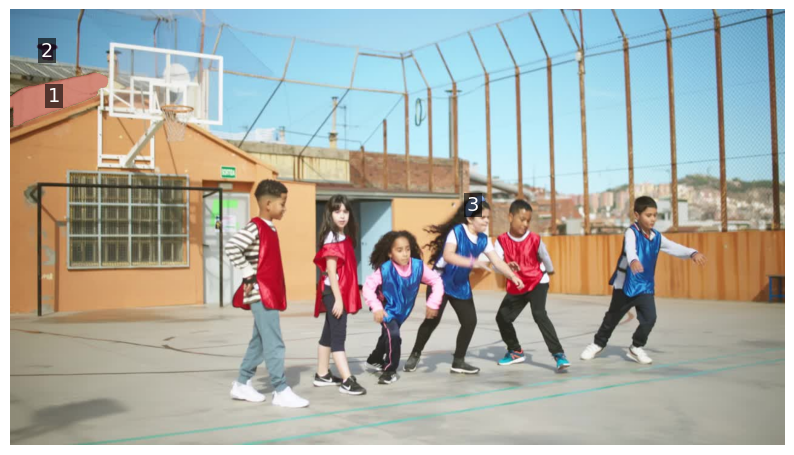

In [6]:

show_masks_on_image(image, masks)